# A pre-mortem produces a risk model. The matrix cannot rank it.

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/phoebefu6/phoebe-the-builder/blob/main/mini-saas-products/pre-mortem/demo.ipynb)
[![Binder](https://mybinder.org/badge_logo.svg)](https://mybinder.org/v2/gh/phoebefu6/phoebe-the-builder/main?labpath=mini-saas-products/pre-mortem/demo.ipynb)

**Day 156 of the FDE portfolio.**

A pre-mortem is cheap and it works. Assume the project already failed, then write
down why - prospective hindsight beats "what could go wrong", because a completed
event is easier to explain than a hypothetical one.

The problem is what happens next. The output is a list of failure modes, and
almost every organisation scores that list on a **5x5 risk matrix**: likelihood
band times impact band. That step is not a convenience, it is a lossy transform,
and Cox (2008) showed qualitative matrices cannot reproduce the ordering of the
quantitative risks they summarise.

| § | |
|---|---|
| 1 | Twelve steps nobody would call risky, and a plan that is a coin flip |
| 2 | Independence was the optimistic assumption |
| 3 | Fourteen causes and the four numbers each one needs |
| 4 | The matrix ranks a quarter of the pairs backwards |
| 5 | It buries the largest risk in the register |
| 6 | Two conventional scales, a different top risk |
| 7 | It was never a ranking problem - it is a knapsack |
| 8 | Try your own |

## 1. Twelve steps nobody would call risky

Every number below is the kind of confidence a competent engineer states out
loud. Not one is alarming. The product is.

In [1]:
from __future__ import annotations

import itertools
import math

import numpy as np

RNG_SEED = 20260826

PLAN = [
    ("Stand up the new warehouse", 0.99),
    ("Replicate historical data", 0.96),
    ("Row counts reconcile", 0.93),
    ("Rewrite the 40 heaviest queries", 0.92),
    ("Semantics match on the top 20 metrics", 0.90),
    ("dbt models build green", 0.95),
    ("Downstream dashboards repoint", 0.94),
    ("Access rules survive the move", 0.97),
    ("Nightly SLA still met", 0.91),
    ("Cost lands inside budget", 0.88),
    ("Cutover weekend runs clean", 0.93),
    ("Two weeks with no rollback", 0.95),
]

print(f"{'step':<44}{'P(works)':>10}{'P(all so far)':>15}")
print("-" * 70)
running = 1.0
for name, p in PLAN:
    running *= p
    print(f"{name:<44}{p:>10.2f}{running:>15.3f}")

plan_success = running
weakest = min(p for _n, p in PLAN)
avg = float(np.mean([p for _n, p in PLAN]))
print(f"\nWeakest single step: {weakest:.2f}.  Whole plan: {plan_success:.3f}.")
print(f"At the average step quality, {math.ceil(math.log(0.5)/math.log(avg))} steps is a coin flip.")
print("\nNobody in the room stated 45%. Each person stated a number about their own")
print("step, and the plan's number was never computed because no one person owned it.")

step                                          P(works)  P(all so far)
----------------------------------------------------------------------
Stand up the new warehouse                        0.99          0.990
Replicate historical data                         0.96          0.950
Row counts reconcile                              0.93          0.884
Rewrite the 40 heaviest queries                   0.92          0.813
Semantics match on the top 20 metrics             0.90          0.732
dbt models build green                            0.95          0.695
Downstream dashboards repoint                     0.94          0.654
Access rules survive the move                     0.97          0.634
Nightly SLA still met                             0.91          0.577
Cost lands inside budget                          0.88          0.508
Cutover weekend runs clean                        0.93          0.472
Two weeks with no rollback                        0.95          0.449

Weakest single ste

## 2. And that assumed the steps are independent

Independence is not the neutral assumption, it is the favourable one. Add one
common cause - the engineer who knows the old system leaves, the vendor slips -
and survival falls below the product rule.

In [2]:
def correlated(rho_shock=0.12, mult=3.0, n=400_000, seed=RNG_SEED):
    rng = np.random.default_rng(seed)
    p_fail = np.array([1 - p for _n, p in PLAN])
    shock = rng.random(n) < rho_shock
    draws = rng.random((n, len(PLAN)))
    scaled = np.where(shock[:, None], np.minimum(p_fail * mult, 1.0), p_fail)
    return float((draws >= scaled).all(axis=1).mean())


corr = correlated()
print(f"independent product rule   {plan_success:.3f}")
print(f"with one common shock      {corr:.3f}")
print(f"gap                        {plan_success - corr:.3f}")
print("\nThe product rule is already the optimistic answer. Every shared dependency -")
print("one person, one vendor, one weekend - moves it down again.")

independent product rule   0.449
with one common shock      0.402
gap                        0.047

The product rule is already the optimistic answer. Every shared dependency -
one person, one vendor, one weekend - moves it down again.


## 3. Fourteen causes, and the four numbers each needs

A cause is not a category. "Data quality issues" cannot be ranked, priced or
prevented; a mechanism can.

`probability` and `loss` are what the matrix throws away. `prevention_cost` and
`prevention_effect` are what nobody records - and they are the two numbers that
decide what actually gets done this week.

In [3]:
# id, cause, probability, loss, prevention_cost, prevention_effect
MODES = [
    ("F01", "Metric definitions silently differ between the two engines", 0.55, 400_000, 25_000, 0.70),
    ("F02", "The one engineer who knows the legacy warehouse leaves", 0.18, 900_000, 40_000, 0.55),
    ("F03", "Query costs land 3x over budget and finance halts the project", 0.30, 600_000, 15_000, 0.80),
    ("F04", "Historical data fails to reconcile", 0.35, 500_000, 30_000, 0.65),
    ("F05", "Timezone handling changes and every daily report shifts a day", 0.40, 120_000, 6_000, 0.85),
    ("F06", "Access rules do not survive the move; someone sees salaries", 0.08, 4_000_000, 45_000, 0.75),
    ("F07", "Nightly SLA slips and the exec dashboard is empty at 8am", 0.45, 90_000, 12_000, 0.70),
    ("F08", "Cutover overruns; Monday opens half-migrated", 0.22, 1_100_000, 60_000, 0.60),
    ("F09", "Three dashboards are missed for a quarter", 0.50, 60_000, 5_000, 0.90),
    ("F10", "Vendor slips the contract date and the window closes", 0.15, 700_000, 20_000, 0.30),
    ("F11", "A float rounding change moves revenue by a cent per row", 0.28, 250_000, 8_000, 0.80),
    ("F12", "Nobody owns the rollback and the decision takes four days", 0.20, 800_000, 10_000, 0.75),
    ("F13", "The migration succeeds and nobody uses the new warehouse", 0.33, 350_000, 18_000, 0.45),
    ("F14", "A regulator asks for lineage during the transition", 0.06, 2_500_000, 35_000, 0.70),
]

IDS = [m[0] for m in MODES]
E = {m[0]: m[2] * m[3] for m in MODES}                       # expected loss
PV = {m[0]: m[2] * m[5] * m[3] - m[4] for m in MODES}        # prevention value
PR = {m[0]: (m[2] * m[5] * m[3]) / m[4] for m in MODES}      # loss avoided per unit spent
COST = {m[0]: m[4] for m in MODES}
AVOID = {m[0]: m[2] * m[5] * m[3] for m in MODES}

print(f"{'id':<5}{'P':>6}{'loss':>11}{'E[loss]':>11}{'prev cost':>11}{'value':>11}")
print("-" * 56)
for i, cause, p, loss, pc, pe in MODES:
    print(f"{i:<5}{p:>6.2f}{loss:>11,}{E[i]:>11,.0f}{pc:>11,}{PV[i]:>11,.0f}")
print(f"\nTotal expected loss: {sum(E.values()):,.0f}")

id        P       loss    E[loss]  prev cost      value
--------------------------------------------------------
F01    0.55    400,000    220,000     25,000    129,000
F02    0.18    900,000    162,000     40,000     49,100
F03    0.30    600,000    180,000     15,000    129,000
F04    0.35    500,000    175,000     30,000     83,750
F05    0.40    120,000     48,000      6,000     34,800
F06    0.08  4,000,000    320,000     45,000    195,000
F07    0.45     90,000     40,500     12,000     16,350
F08    0.22  1,100,000    242,000     60,000     85,200
F09    0.50     60,000     30,000      5,000     22,000
F10    0.15    700,000    105,000     20,000     11,500
F11    0.28    250,000     70,000      8,000     48,000
F12    0.20    800,000    160,000     10,000    110,000
F13    0.33    350,000    115,500     18,000     33,975
F14    0.06  2,500,000    150,000     35,000     70,000

Total expected loss: 2,018,000


## 4. The matrix ranks a quarter of the pairs backwards

Two scales, both the shape found in real corporate risk templates. Bands are
**1-indexed** on purpose: a band of 0 would zero the product and make the whole
bottom row score 0 at every impact.

An *inversion* is a pair where the matrix score of A exceeds B while A's expected
loss is **smaller**. Not imprecision - the wrong direction.

In [4]:
SCALES = {
    "corporate-5x5": ((0.05, 0.20, 0.50, 0.80), (50_000, 250_000, 1_000_000, 5_000_000)),
    "audit-5x5":     ((0.10, 0.25, 0.50, 0.75), (100_000, 500_000, 2_000_000, 10_000_000)),
}


def bands(scale, p, loss):
    p_edges, l_edges = SCALES[scale]
    return (int(np.searchsorted(p_edges, p, side="right")) + 1,
            int(np.searchsorted(l_edges, loss, side="right")) + 1)


def score(scale, m):
    pb, lb = bands(scale, m[2], m[3])
    return pb * lb


def quality(scale):
    pairs = list(itertools.combinations(MODES, 2))
    ordered = inv = 0
    inversions = []
    for a, b in pairs:
        sa, sb = score(scale, a), score(scale, b)
        if sa == sb:
            continue
        ordered += 1
        hi, lo = (a, b) if sa > sb else (b, a)
        if E[hi[0]] < E[lo[0]]:
            inv += 1
            inversions.append((hi[0], lo[0], E[lo[0]] / E[hi[0]]))
    return {"pairs": len(pairs), "ordered": ordered, "tied": len(pairs) - ordered,
            "inversions": inv, "rate": inv / ordered,
            "undecided": (len(pairs) - ordered) / len(pairs),
            "worst": sorted(inversions, key=lambda r: -r[2])[:4]}


for name in SCALES:
    q = quality(name)
    print(f"{name:<16} pairs {q['pairs']}  ordered {q['ordered']}  tied {q['tied']}  "
          f"inverted {q['inversions']} ({q['rate']:.1%})  cannot order {q['undecided']:.1%}")

print("\nWorst inversions on corporate-5x5:")
for hi, lo, ratio in quality("corporate-5x5")["worst"]:
    print(f"    {hi} scores above {lo}, and {lo} carries {ratio:.1f}x the expected loss")

corporate-5x5    pairs 91  ordered 71  tied 20  inverted 18 (25.4%)  cannot order 22.0%
audit-5x5        pairs 91  ordered 66  tied 25  inverted 20 (30.3%)  cannot order 27.5%

Worst inversions on corporate-5x5:
    F09 scores above F02, and F02 carries 5.4x the expected loss
    F11 scores above F06, and F06 carries 4.6x the expected loss
    F09 scores above F10, and F10 carries 3.5x the expected loss
    F13 scores above F06, and F06 carries 2.8x the expected loss


## 5. It buries the largest risk in the register

F06 is a 0.08 chance of a 4,000,000 loss - the single largest expected loss here.
Low probability drags the likelihood band down, and the band is all the score
sees.

In [5]:
def order_by_matrix(scale):
    return [m[0] for m in sorted(MODES, key=lambda m: (-score(scale, m), -E[m[0]]))]


m_order = order_by_matrix("corporate-5x5")
e_order = [i for i in sorted(IDS, key=lambda i: -E[i])]
v_order = [i for i in sorted(IDS, key=lambda i: -PV[i])]

f06 = next(m for m in MODES if m[0] == "F06")
print(f"F06: P={f06[2]:.2f}  loss={f06[3]:,}  expected loss={E['F06']:,.0f}")
print(f"     cell {bands('corporate-5x5', f06[2], f06[3])}  score {score('corporate-5x5', f06)}\n")
print(f"    rank by matrix score      {m_order.index('F06') + 1} of {len(MODES)}")
print(f"    rank by expected loss     {e_order.index('F06') + 1}")
print(f"    rank by prevention value  {v_order.index('F06') + 1}")

print(f"\nmatrix top 3          {m_order[:3]}")
print(f"expected loss top 3   {e_order[:3]}")
print(f"prevention top 3      {v_order[:3]}")
print("\nOnly the last ordering knows what prevention COSTS, which is the only")
print("question the meeting was held to answer. The matrix never asked.")

F06: P=0.08  loss=4,000,000  expected loss=320,000
     cell (2, 4)  score 8

    rank by matrix score      8 of 14
    rank by expected loss     1
    rank by prevention value  1

matrix top 3          ['F08', 'F01', 'F03']
expected loss top 3   ['F06', 'F08', 'F01']
prevention top 3      ['F06', 'F01', 'F03']

Only the last ordering knows what prevention COSTS, which is the only
question the meeting was held to answer. The matrix never asked.


## 6. Two conventional scales, a different top risk

The single most consequential output of the exercise depends on which template
the organisation happens to have downloaded.

In [6]:
flips = []
for a, b in itertools.combinations(MODES, 2):
    aa, ab = score("corporate-5x5", a), score("corporate-5x5", b)
    ba, bb = score("audit-5x5", a), score("audit-5x5", b)
    if aa == ab or ba == bb:
        continue
    if (aa > ab) != (ba > bb):
        flips.append((a[0], b[0]))

top_a = order_by_matrix("corporate-5x5")[0]
top_b = order_by_matrix("audit-5x5")[0]
print(f"{len(flips)} pairs are ordered oppositely by the two scales.")
print(f"Top risk under corporate-5x5: {top_a}")
print(f"Top risk under audit-5x5    : {top_b}")
print(f"Same top risk: {top_a == top_b}")

# And the arithmetic itself: band x band is a number with no unit.
cells = {}
for pb in range(1, 6):
    for lb in range(1, 6):
        cells.setdefault(pb * lb, []).append((pb, lb))
collide = {k: v for k, v in cells.items() if len(v) > 1}
print(f"\n25 cells collapse to {len(cells)} distinct scores; {len(collide)} scores are shared.")
print(f"Score 12 is produced by {cells[12]} - a 30% chance of 2,000,000 and a 60%")
print("chance of 500,000 score identically. Their expected losses differ by 2x.")

13 pairs are ordered oppositely by the two scales.
Top risk under corporate-5x5: F08
Top risk under audit-5x5    : F03
Same top risk: False

25 cells collapse to 14 distinct scores; 10 scores are shared.
Score 12 is produced by [(3, 4), (4, 3)] - a 30% chance of 2,000,000 and a 60%
chance of 500,000 score identically. Their expected losses differ by 2x.


## 7. It was never a ranking problem

Prevention is bought under a budget, so the decision is which **set** to buy -
and no ordering is guaranteed to find the best set. Here is the exact answer by
brute force over all 16,384 subsets, against both heuristics.

In [7]:
def greedy(order, budget):
    left, avoided = budget, 0.0
    bought = []
    for i in order:
        if COST[i] <= left and PV[i] > 0:
            left -= COST[i]
            avoided += AVOID[i]
            bought.append(i)
    return bought, avoided


def optimal(budget):
    n = len(MODES)
    best, best_av = (), 0.0
    for mask in range(1 << n):
        cost = av = 0.0
        for k in range(n):
            if mask >> k & 1:
                cost += COST[IDS[k]]
                if cost > budget:
                    break
                av += AVOID[IDS[k]]
        else:
            if cost <= budget and av > best_av:
                best_av, best = av, tuple(IDS[k] for k in range(n) if mask >> k & 1)
    return best, best_av


ratio_order = sorted(IDS, key=lambda i: -PR[i])
print(f"{'budget':>9}{'matrix':>12}{'ratio':>12}{'optimal':>12}{'matrix short':>14}")
print("-" * 60)
for b in (50_000, 100_000, 150_000, 200_000):
    _mb, mav = greedy(m_order, b)
    _rb, rav = greedy(ratio_order, b)
    _ob, oav = optimal(b)
    print(f"{b:>9,}{mav:>12,.0f}{rav:>12,.0f}{oav:>12,.0f}{oav - mav:>14,.0f}")

_ob, oav = optimal(100_000)
_mb, mav = greedy(m_order, 100_000)
print(f"\nAt 100,000 the matrix ordering buys {mav:,.0f} where {oav:,.0f} was available -")
print(f"it leaves {(oav - mav) / oav:.0%} of the achievable benefit unbought.")
print(f"Optimal set: {list(_ob)}")
print("\nAnd the honest part: at 50,000 the RATIO heuristic loses to the matrix.")
print("Greedy-by-ratio is a knapsack heuristic, not a solution. Neither ordering is")
print("reliable - which is the argument for not ordering at all. The exact solve above")
print("runs in well under a second on fourteen items.")

   budget      matrix       ratio     optimal  matrix short
------------------------------------------------------------
   50,000     418,000     387,800     418,000             0
  100,000     443,200     655,550     685,000       241,800
  150,000     732,950     895,550     895,550       162,600
  200,000     884,225   1,052,525   1,052,525       168,300

At 100,000 the matrix ordering buys 443,200 where 685,000 was available -
it leaves 35% of the achievable benefit unbought.
Optimal set: ['F01', 'F03', 'F06', 'F09', 'F12']

And the honest part: at 50,000 the RATIO heuristic loses to the matrix.
Greedy-by-ratio is a knapsack heuristic, not a solution. Neither ordering is
reliable - which is the argument for not ordering at all. The exact solve above
runs in well under a second on fourteen items.


## The picture

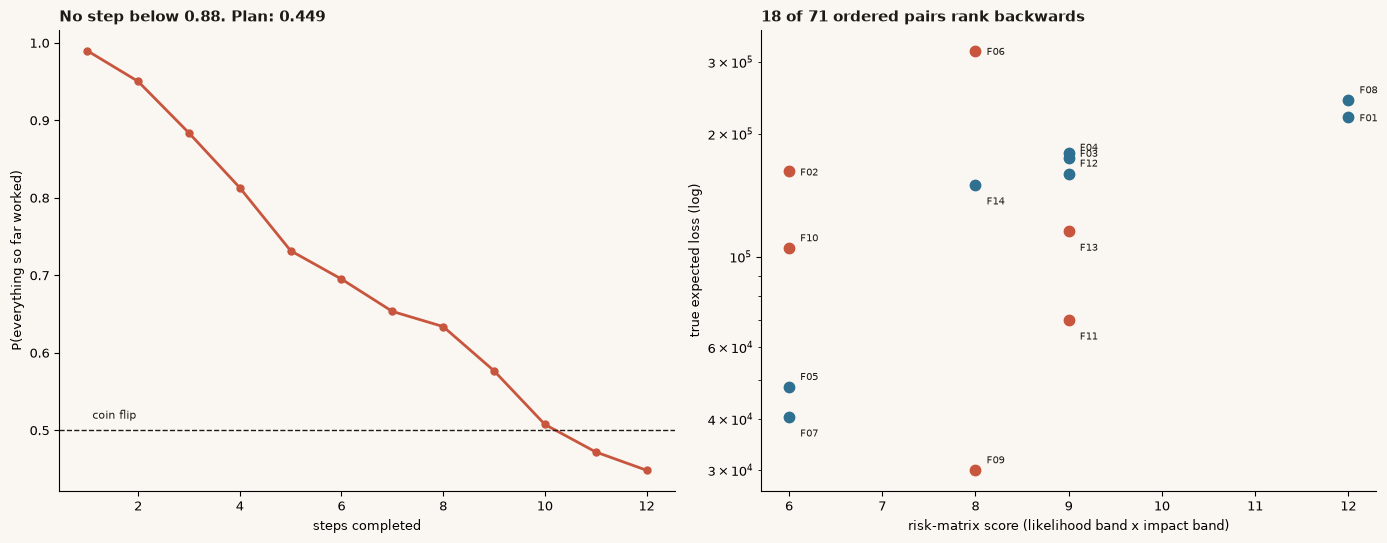

In [8]:
import matplotlib.pyplot as plt

INK, GRIDC, PAPER = "#1d1a17", "#e3ddd5", "#faf7f2"
ACCENT, COOL, WARM, GREEN = "#c8553d", "#2f6f8f", "#e0a458", "#4f7942"
plt.rcParams.update({"figure.facecolor": PAPER, "axes.facecolor": PAPER,
                     "text.color": INK, "font.size": 9})

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5.5))

run, ys = 1.0, []
for _n, p in PLAN:
    run *= p
    ys.append(run)
ax1.plot(range(1, len(PLAN) + 1), ys, "o-", color=ACCENT, ms=5, lw=2)
ax1.axhline(0.5, color=INK, lw=1, ls="--")
ax1.text(1.1, 0.515, "coin flip", fontsize=8)
ax1.set_xlabel("steps completed")
ax1.set_ylabel("P(everything so far worked)")
ax1.set_title(f"No step below {weakest:.2f}. Plan: {ys[-1]:.3f}",
              loc="left", fontweight="bold")
for s in ("top", "right"):
    ax1.spines[s].set_visible(False)

q = quality("corporate-5x5")
inv_ids = {a for a, _b, _r in q["worst"]} | {b for _a, b, _r in q["worst"]}
seen = {}
for m in MODES:
    x, y = score("corporate-5x5", m), E[m[0]]
    ax2.scatter([x], [y], s=56, color=ACCENT if m[0] in inv_ids else COOL, zorder=3)
    k = seen.get(x, 0)
    seen[x] = k + 1
    ax2.annotate(m[0], (x, y), textcoords="offset points",
                 xytext=(8, -3 + (0 if k == 0 else (8 if k % 2 else -11))), fontsize=7)
ax2.set_yscale("log")
ax2.set_xlabel("risk-matrix score (likelihood band x impact band)")
ax2.set_ylabel("true expected loss (log)")
ax2.set_title(f"{q['inversions']} of {q['ordered']} ordered pairs rank backwards",
              loc="left", fontweight="bold")
for s in ("top", "right"):
    ax2.spines[s].set_visible(False)

fig.tight_layout()
fig.savefig("notebook_premortem.png", dpi=140, facecolor=PAPER)
plt.show()

## 8. Try your own

Put your last project's failure modes in. The two columns most registers are
missing are the last two, and they are the only two that decide anything.

In [9]:
# MY_MODES = [
#     # id, cause, probability, loss, prevention_cost, prevention_effect
#     ("R01", "describe the mechanism, not the category", 0.30, 250_000, 10_000, 0.6),
#     ("R02", "another mechanism", 0.10, 900_000, 25_000, 0.5),
# ]
#
# for i, cause, p, loss, pc, pe in MY_MODES:
#     e = p * loss
#     avoided = p * pe * loss
#     pb, lb = bands("corporate-5x5", p, loss)
#     print(f"{i}  E[loss]={e:>10,.0f}  matrix score={pb*lb:>3}  "
#           f"prevention value={avoided - pc:>10,.0f}  ratio={avoided/pc:>5.1f}x")
#
# ids = [m[0] for m in MY_MODES]
# by_matrix = sorted(MY_MODES, key=lambda m: -(bands("corporate-5x5", m[2], m[3])[0]
#                                              * bands("corporate-5x5", m[2], m[3])[1]))
# by_value = sorted(MY_MODES, key=lambda m: -(m[2] * m[5] * m[3] - m[4]))
# print("\nmatrix order    :", [m[0] for m in by_matrix])
# print("prevention order:", [m[0] for m in by_value])
# if [m[0] for m in by_matrix] != [m[0] for m in by_value]:
#     print("These disagree. The second one knows what prevention costs.")

## What to keep

1. **Run the pre-mortem.** Prospective hindsight surfaces more and more specific
   causes than asking what might go wrong, and it costs an hour.
2. **Compute the plan's own probability.** Twelve steps at 95% is not 95%, and
   independence is the optimistic assumption on top of that.
3. **Demand a mechanism, not a category.** If it cannot take a probability, it is
   not a finding yet.
4. **Record four numbers per cause** - probability, loss, cost to reduce it, and
   how much of it the spend removes. The last two are the ones nobody writes down
   and the only two that decide anything.
5. **Do not score it on a matrix.** On this register the default 5x5 inverts a
   quarter of the pairs it orders, cannot order a fifth of them at all, and puts
   the largest expected loss eighth.
6. **Then stop ranking.** Name the budget and solve for the best set. It is a
   knapsack, it is exact, and it is instant at the size any real register is.

---

**Full audit:** `python evidence.py` in
[`mini-saas-products/pre-mortem`](https://github.com/phoebefu6/phoebe-the-builder/tree/main/mini-saas-products/pre-mortem) prints all twelve sections;
`pytest` asserts every number on this page.

**Interactive:** `streamlit run app.py` - paste a register, see the orderings disagree.

Part of [phoebe-the-builder](https://github.com/phoebefu6/phoebe-the-builder) - one small, real tool a day.